# 02 — Snap & Join Quality EDA

Explores the quality of collision → road link snapping using `snap.py` outputs.
Loads from saved parquets — no need to re-run the pipeline.

**Key findings:**
- SD→SE BNG grid letter error: 9 corrected, ~60k unrecoverable wrong coordinates
- Snap rate ceiling: 40.6% of 2015–2024 Yorkshire collisions
- Weighted vs quick snap agreement: 59.6% on matched collisions
- Mean snap distance: 14.5m, mean composite score: 0.878

In [51]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from road_risk.config import _ROOT

PROCESSED = _ROOT / 'data/processed'
FEATURES  = _ROOT / 'data/features'
print(f'Project root: {_ROOT}')

Project root: /home/tsispace/Documents/GitHub/road-risk-analysis


## 1. Load data

In [52]:
collisions = pd.read_parquet(PROCESSED / 'stats19/collision_clean.parquet')
snapped_w  = pd.read_parquet(PROCESSED / 'stats19/snapped_weighted.parquet')
snapped_q  = pd.read_parquet(PROCESSED / 'stats19/snapped_quick.parquet')
openroads  = gpd.read_parquet(PROCESSED / 'shapefiles/openroads_yorkshire.parquet')

print(f'Collisions      : {len(collisions):,}')
print(f'Snapped weighted: {len(snapped_w):,}')
print(f'OS Open Roads   : {len(openroads):,} links')

Collisions      : 101,567
Snapped weighted: 101,567
OS Open Roads   : 705,672 links


## 2. Coordinate quality — SD→SE error

In [53]:
print('Coordinate flags:')
print(f"  coords_valid=True  : {collisions['coords_valid'].sum():,} ({collisions['coords_valid'].mean():.1%})")
print(f"  coords_corrected   : {collisions['coords_corrected'].sum():,} (SD→SE fix applied)")
print(f"  coords_suspect     : {collisions['coords_suspect'].sum():,}")
print(f"  invalid in snap    : {(snapped_w['snap_method']=='invalid_coords').sum():,}")
print(f"\nlsoa_dist_m stats:")
print(collisions['lsoa_dist_m'].describe().round(0))

Coordinate flags:
  coords_valid=True  : 101,518 (100.0%)
  coords_corrected   : 9 (SD→SE fix applied)
  coords_suspect     : 20
  invalid in snap    : 49

lsoa_dist_m stats:
count    96937.0
mean       666.0
std       1338.0
min          0.0
25%        214.0
50%        349.0
75%        638.0
max      99660.0
Name: lsoa_dist_m, dtype: float64


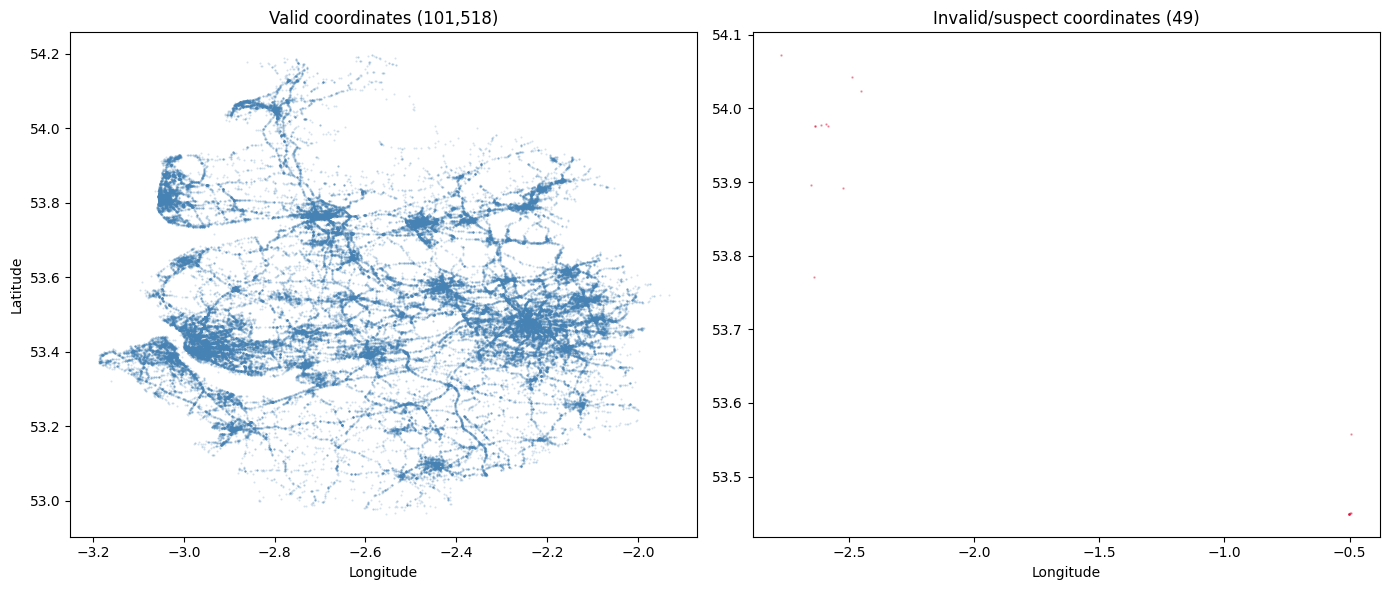

In [54]:
# Map valid vs invalid coordinates
valid   = collisions[collisions['coords_valid'] == True]
invalid = collisions[collisions['coords_valid'] == False]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(valid['longitude'], valid['latitude'], s=0.3, alpha=0.2, color='steelblue')
axes[0].set_title(f'Valid coordinates ({len(valid):,})')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

axes[1].scatter(invalid['longitude'], invalid['latitude'], s=0.5, alpha=0.4, color='crimson')
axes[1].set_title(f'Invalid/suspect coordinates ({len(invalid):,})')
axes[1].set_xlabel('Longitude')

plt.tight_layout()
plt.show()

In [55]:
# Invalid coords breakdown by year
invalid_by_year = (
    collisions.groupby('collision_year')
    .agg(total=('collision_index','count'),
         invalid=('coords_valid', lambda x: (~x).sum()))
)
invalid_by_year['pct_invalid'] = (invalid_by_year['invalid'] / invalid_by_year['total']).map('{:.1%}'.format)
print(invalid_by_year.to_string())

                total  invalid pct_invalid
collision_year                            
2015            11812        5        0.0%
2016            11446        5        0.0%
2017            11875        5        0.0%
2018            11457        5        0.0%
2019            10449        6        0.1%
2020             7833        3        0.0%
2021             9318        4        0.0%
2022             9521       10        0.1%
2023             8955        4        0.0%
2024             8901        2        0.0%


## 3. Snap method breakdown

In [56]:
for label, df in [('Weighted', snapped_w), ('Quick', snapped_q)]:
    print(f'=== {label} snap ===')
    for method, count in df['snap_method'].value_counts().items():
        print(f'  {method:20s}: {count:>8,}  ({count/len(df):.1%})')
    print()

=== Weighted snap ===
  unmatched           :   60,302  (59.4%)
  weighted            :   41,216  (40.6%)
  invalid_coords      :       49  (0.0%)

=== Quick snap ===
  unmatched           :   60,301  (59.4%)
  spatial             :   41,217  (40.6%)
  invalid_coords      :       49  (0.0%)



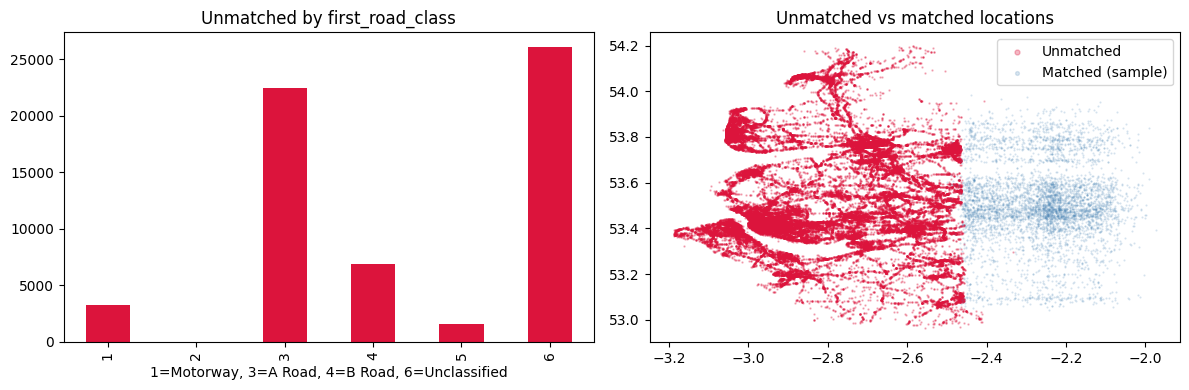

Unmatched lon range: -3.188 → -2.333
Matched   lon range: -2.505 → -1.932

Unmatched cluster west of Yorkshire (lon < -2.5) — genuine coordinate errors


In [57]:
# Unmatched collisions — road class and location
unmatched = snapped_w[snapped_w['snap_method'] == 'unmatched']
matched   = snapped_w[snapped_w['snap_method'] == 'weighted']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
unmatched['first_road_class'].value_counts().sort_index().plot.bar(ax=axes[0], color='crimson')
axes[0].set_title('Unmatched by first_road_class')
axes[0].set_xlabel('1=Motorway, 3=A Road, 4=B Road, 6=Unclassified')

axes[1].scatter(unmatched['longitude'], unmatched['latitude'], s=0.5, alpha=0.3, color='crimson', label='Unmatched')
axes[1].scatter(matched['longitude'].sample(5000), matched['latitude'].sample(5000),
                s=0.3, alpha=0.2, color='steelblue', label='Matched (sample)')
axes[1].set_title('Unmatched vs matched locations')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

print(f'Unmatched lon range: {unmatched["longitude"].min():.3f} → {unmatched["longitude"].max():.3f}')
print(f'Matched   lon range: {matched["longitude"].min():.3f} → {matched["longitude"].max():.3f}')
print('\nUnmatched cluster west of Yorkshire (lon < -2.5) — genuine coordinate errors')

## 4. Weighted snap score quality

In [58]:
matched_w = snapped_w[snapped_w['snap_method'] == 'weighted'].copy()
matched_w = matched_w.merge(
    openroads[['link_id','road_classification','form_of_way']],
    on='link_id', how='left'
)

print('Score summary:')
print(matched_w['snap_score'].describe().round(3))
print('\nMean score by dimension:')
score_dims = ['score_spatial','score_class','score_junction','score_number']
print(matched_w[score_dims].mean().round(3))

Score summary:
count    41216.000
mean         0.878
std          0.095
min          0.114
25%          0.820
50%          0.865
75%          0.950
max          1.000
Name: snap_score, dtype: float64

Mean score by dimension:
score_spatial     0.925
score_class       0.962
score_junction    0.760
score_number      0.777
dtype: float64


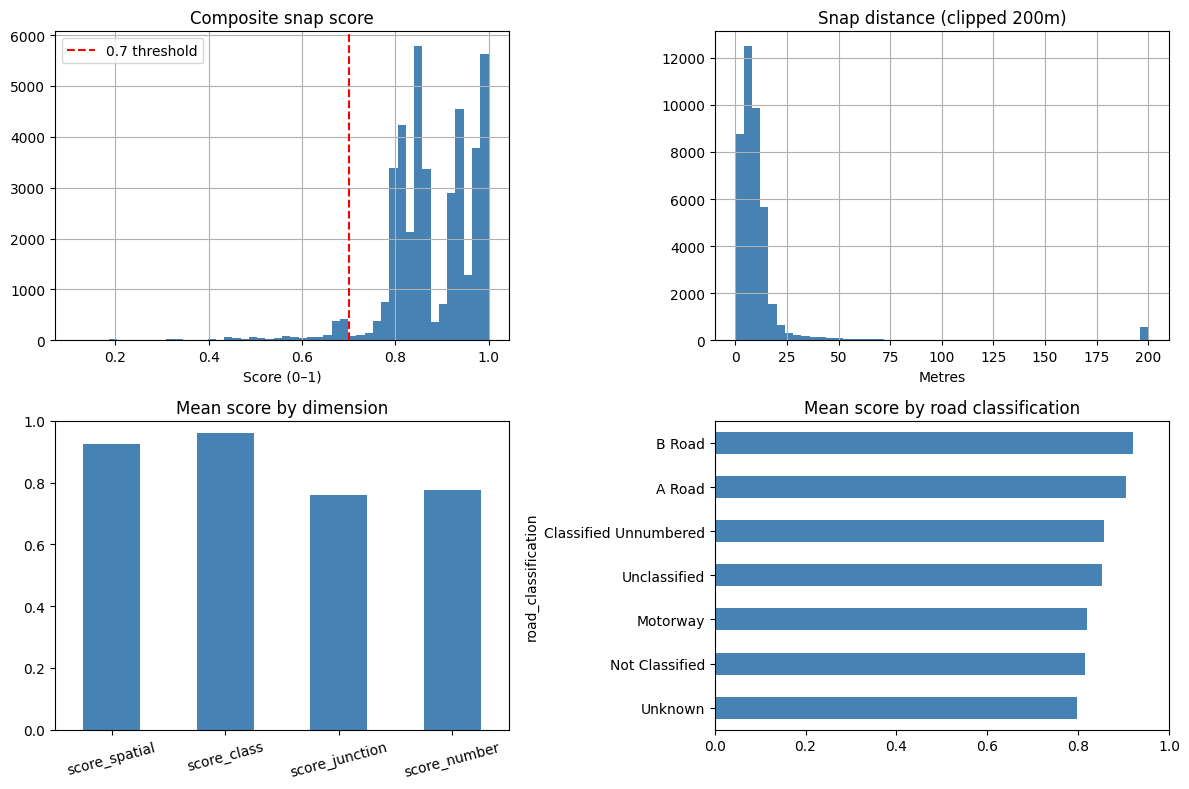

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

matched_w['snap_score'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='none')
axes[0,0].axvline(0.7, color='red', linestyle='--', label='0.7 threshold')
axes[0,0].set_title('Composite snap score')
axes[0,0].set_xlabel('Score (0–1)')
axes[0,0].legend()

matched_w['snap_distance_m'].clip(upper=200).hist(bins=50, ax=axes[0,1], color='steelblue', edgecolor='none')
axes[0,1].set_title('Snap distance (clipped 200m)')
axes[0,1].set_xlabel('Metres')

matched_w[score_dims].mean().plot.bar(ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Mean score by dimension')
axes[1,0].set_ylim(0, 1)
axes[1,0].tick_params(axis='x', rotation=15)

matched_w.groupby('road_classification')['snap_score'].mean().sort_values()\
         .plot.barh(ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Mean score by road classification')
axes[1,1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 5. Weighted vs quick — where do they disagree?

In [60]:
comp = snapped_w[['collision_index','link_id','snap_distance_m','snap_score',
                   'score_class','score_junction','snap_method']].merge(
    snapped_q[['collision_index','link_id','snap_distance_m','snap_method']]
             .rename(columns={'link_id':'q_link_id','snap_distance_m':'q_dist_m','snap_method':'q_method'}),
    on='collision_index'
)

both = comp[(comp['snap_method']=='weighted') & (comp['q_method']=='spatial')].copy()
both['agree'] = both['link_id'] == both['q_link_id']

print(f'Both matched   : {len(both):,}')
print(f'Agree on link  : {both["agree"].sum():,} ({both["agree"].mean():.1%})')
print(f'Disagree       : {(~both["agree"]).sum():,} ({(~both["agree"]).mean():.1%})')

disagree = both[~both['agree']]
print(f'\nWhen they disagree:')
print(f'  Weighted chose closer link : {(disagree["snap_distance_m"] < disagree["q_dist_m"]).sum():,}')
print(f'  Weighted chose further link: {(disagree["snap_distance_m"] > disagree["q_dist_m"]).sum():,}')
print(f'  Mean score_class on disagree: {disagree["score_class"].mean():.3f}')
print(f'  Mean score_junction on disagree: {disagree["score_junction"].mean():.3f}')

Both matched   : 41,216
Agree on link  : 24,573 (59.6%)
Disagree       : 16,643 (40.4%)

When they disagree:
  Weighted chose closer link : 0
  Weighted chose further link: 16,604
  Mean score_class on disagree: 0.959
  Mean score_junction on disagree: 0.870


In [61]:
# Key use case: weighted snap should avoid slip roads for non-junction collisions
non_junc = matched_w[matched_w['junction_detail'] == 0]
print(f'Non-junction collisions (junction_detail=0): {len(non_junc):,}')
print(f'\nSnapped to form_of_way:')
print(non_junc['form_of_way'].value_counts())
print(f'\nSlip road snaps for non-junction collisions: '
      f"{(non_junc['form_of_way']=='Slip Road').sum()} "
      f"({(non_junc['form_of_way']=='Slip Road').mean():.2%})")

Non-junction collisions (junction_detail=0): 17,943

Snapped to form_of_way:
form_of_way
Single Carriageway            12237
Collapsed Dual Carriageway     3713
Roundabout                      789
Slip Road                       785
Dual Carriageway                411
Shared Use Carriageway            8
Name: count, dtype: int64

Slip road snaps for non-junction collisions: 785 (4.37%)


## 6. Score threshold — how strict to be for modelling?

In [62]:
total = len(collisions)
print(f'{'Threshold':>10}  {'Retained':>10}  {'% matched':>10}  {'% all':>10}')
print('-' * 46)
for t in [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]:
    n = (matched_w['snap_score'] >= t).sum()
    print(f'  >= {t:.2f}    {n:>10,}  {n/len(matched_w):>9.1%}  {n/total:>9.1%}')
print(f'  No filter   {len(matched_w):>10,}  {1.0:>9.1%}  {len(matched_w)/total:>9.1%}')

 Threshold    Retained   % matched       % all
----------------------------------------------
  >= 0.50        40,878      99.2%      40.2%
  >= 0.60        40,591      98.5%      40.0%
  >= 0.70        39,543      95.9%      38.9%
  >= 0.75        39,246      95.2%      38.6%
  >= 0.80        35,848      87.0%      35.3%
  >= 0.85        25,210      61.2%      24.8%
  >= 0.90        18,664      45.3%      18.4%
  No filter       41,216     100.0%      40.6%


## 7. Road_link_annual table (if available)

In [63]:
rla_path = FEATURES / 'road_link_annual.parquet'
if rla_path.exists():
    rla = pd.read_parquet(rla_path)
    print(f'road_link_annual: {len(rla):,} rows × {rla.shape[1]} cols')
    print(f'Links: {rla["link_id"].nunique():,} | Years: {sorted(rla["year"].unique())}')
    if 'collision_rate_per_mvkm' in rla.columns:
        print(f'Collision rate median: {rla["collision_rate_per_mvkm"].median():.4f} per M veh-km')
    print(f'\nMissingness (columns with >5% missing):')
    miss = rla.isna().mean()
    print(miss[miss > 0.05].map('{:.1%}'.format))
    print(f'\nBy road classification:')
    print(rla.groupby('road_classification')['collision_count'].agg(['sum','count']))
else:
    print('road_link_annual.parquet not found — run join.py after updating it to use snapped_weighted.parquet')

road_link_annual: 7,093 rows × 37 cols
Links: 4,517 | Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Collision rate median: 0.6924 per M veh-km

Missingness (columns with >5% missing):
count_point_id               99.6%
road_type                    99.6%
latitude                     70.8%
longitude                    70.8%
link_length_km               99.6%
all_motor_vehicles           99.6%
all_hgvs                     99.6%
hgv_proportion               99.6%
lgv_proportion               99.6%
cars_proportion              99.6%
heavy_vehicle_prop           99.6%
estimation_method            99.6%
is_covid                     99.6%
mean_daily_flow              99.6%
large_vehicle_pct            99.6%
mean_weekday_flow            99.6%
large_vehicle_weekday_pct    99.6%
site_id                      99.6%
aadf_snap_distance_m         70.8%
aadf_join_method             